#1.영상의 미분과 소벨 필터

Mounted at /content/gdrive


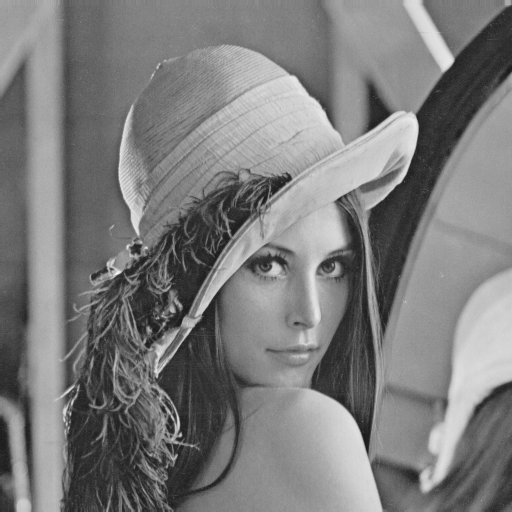

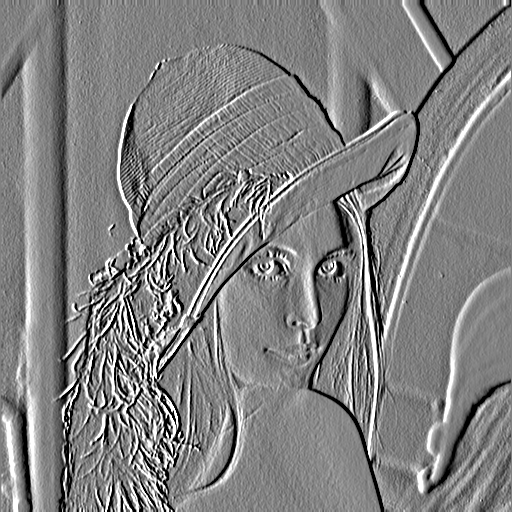

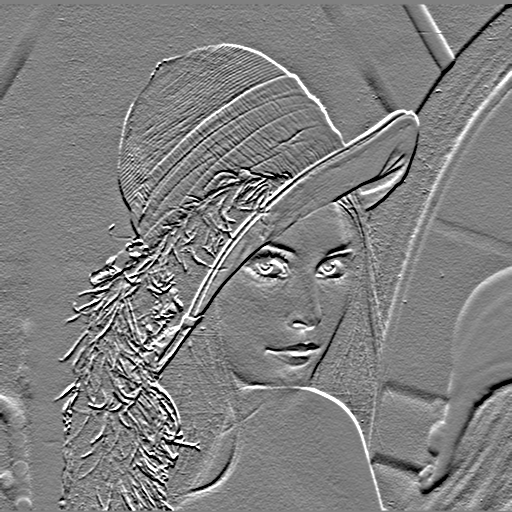

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

from google.colab.patches import cv2_imshow

import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/lenna.bmp', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

dx = cv2.Sobel(src, -1, 1, 0, delta=128)
dy = cv2.Sobel(src, -1, 0, 1, delta=128)

cv2_imshow(src)
cv2_imshow(dx)
cv2_imshow(dy)

# cv2.waitKey()
# cv2.destroyAllWindows()

#2. 그래디언트와 에지 검출

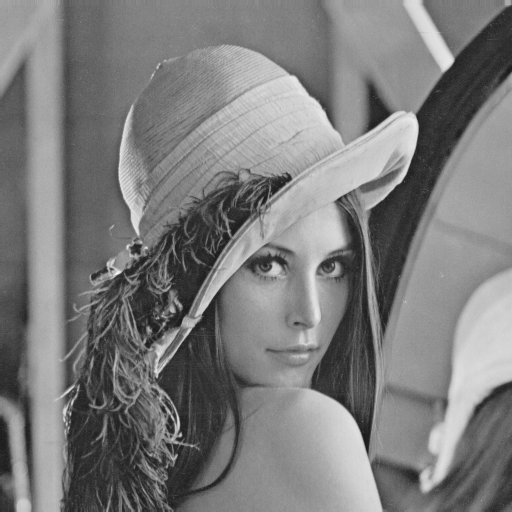

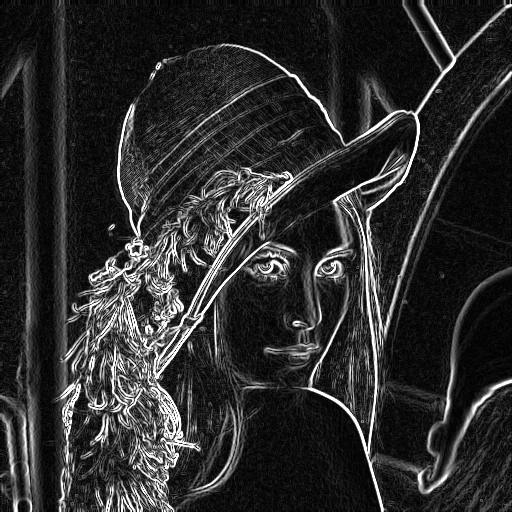

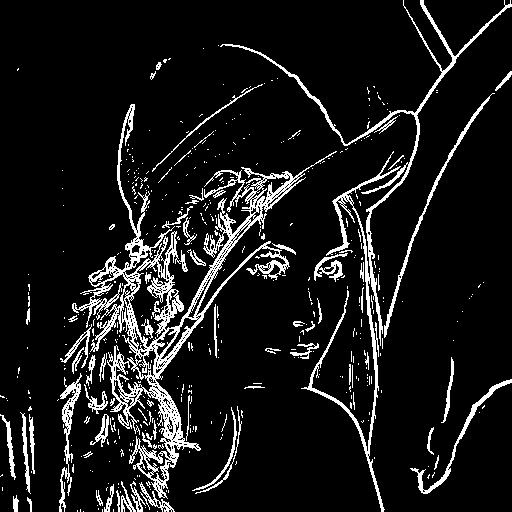

In [3]:
import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/lenna.bmp', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

dx = cv2.Sobel(src, cv2.CV_32F, 1, 0)
dy = cv2.Sobel(src, cv2.CV_32F, 0, 1)

mag = cv2.magnitude(dx, dy)
mag = np.clip(mag, 0, 255).astype(np.uint8)

dst = np.zeros(src.shape[:2], np.uint8)
dst[mag > 120] = 255
#_, dst = cv2.threshold(mag, 120, 255, cv2.THRESH_BINARY)

cv2_imshow(src)
cv2_imshow(mag)
cv2_imshow(dst)

# cv2.waitKey()
# cv2.destroyAllWindows()

#3. 캐니 에지 검출

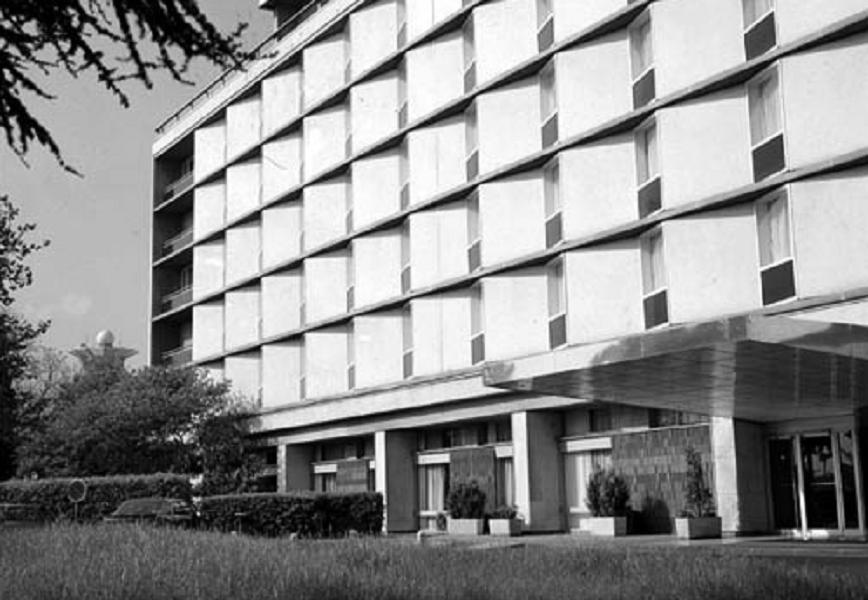

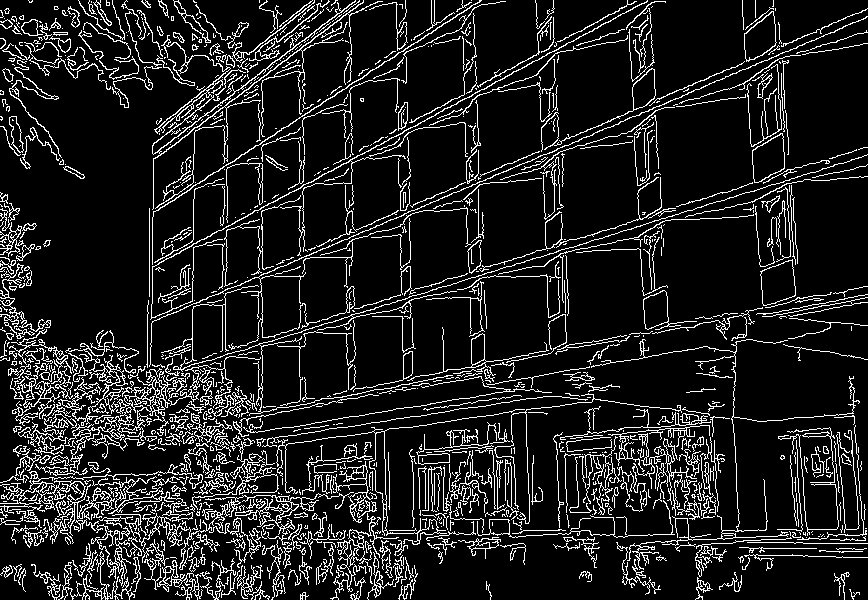

In [5]:
import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/building.jpg', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

dst = cv2.Canny(src, 40, 150)

cv2_imshow(src)
cv2_imshow(dst)

# cv2.waitKey()
# cv2.destroyAllWindows()

#4. 호프 변환 - 직선 검출

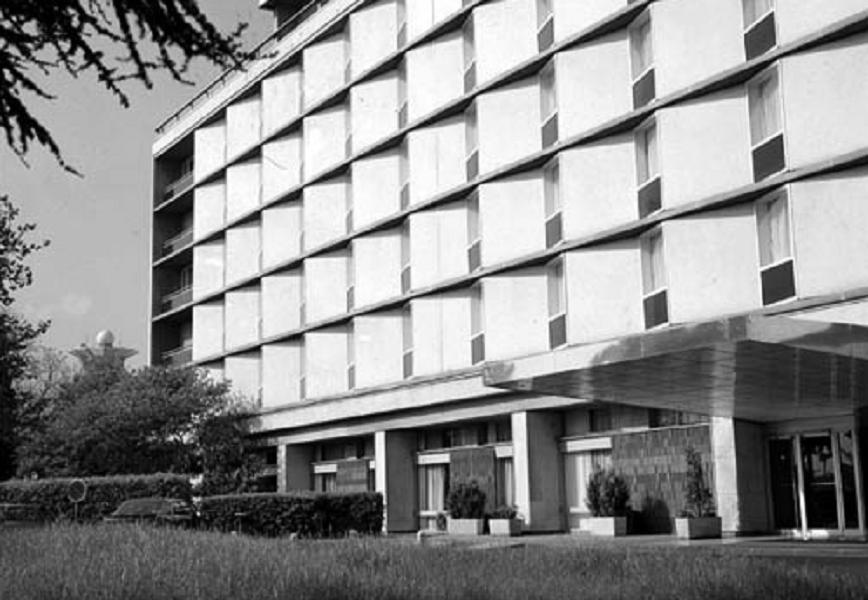

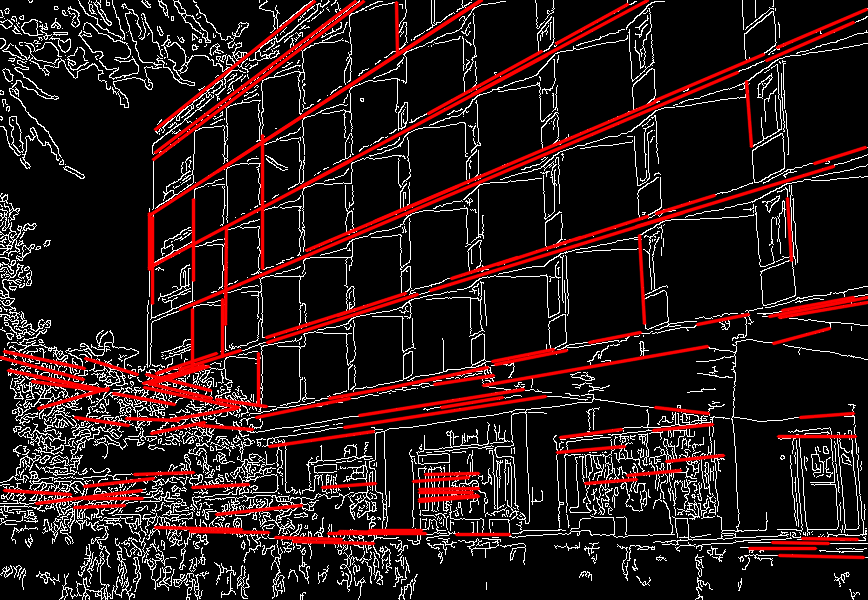

In [ ]:
import sys
import numpy as np
import cv2

src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/building.jpg', cv2.IMREAD_GRAYSCALE)

if src is None:
    print('Image load failed!')
    sys.exit()

edges = cv2.Canny(src, 50, 150)

lines = cv2.HoughLinesP(edges, 1, np.pi / 180., 160,
                        minLineLength=50, maxLineGap=5)

dst = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

if lines is not None:
    for i in range(lines.shape[0]):
        pt1 = (lines[i][0][0], lines[i][0][1])  # 시작점 좌표
        pt2 = (lines[i][0][2], lines[i][0][3])  # 끝점 좌표
        cv2.line(dst, pt1, pt2, (0, 0, 255), 2, cv2.LINE_AA)

cv2_imshow(src)
cv2_imshow(dst)

# cv2.waitKey()
# cv2.destroyAllWindows()

#5. 호프 변환 - 원 검출

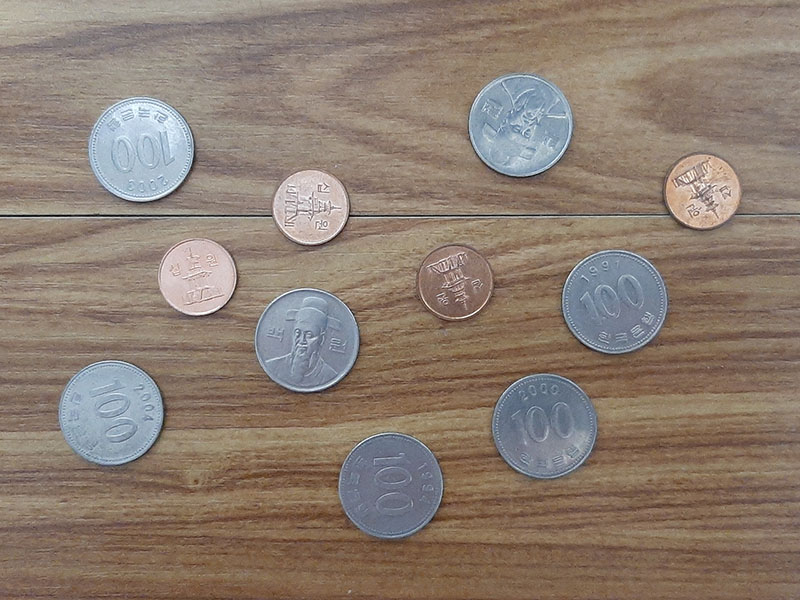

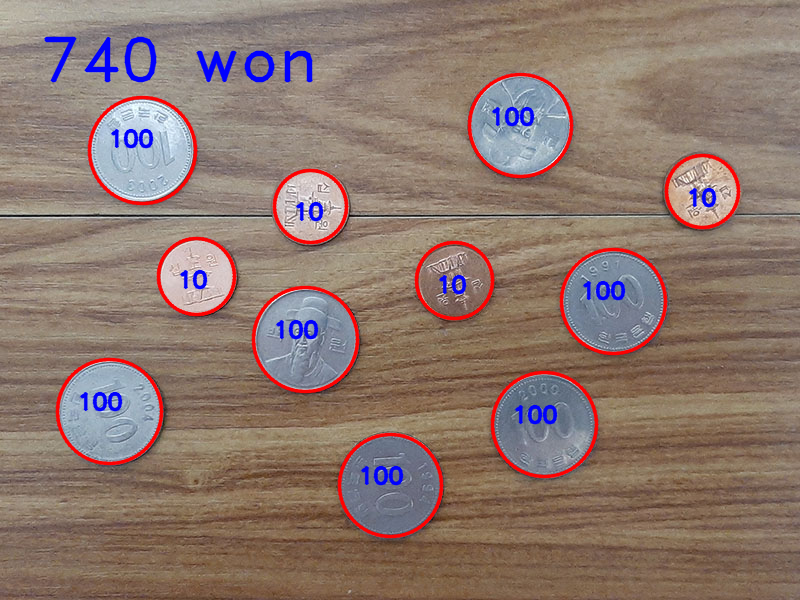

In [ ]:
import sys
import numpy as np
import cv2

# 입력 이미지 불러오기
src = cv2.imread('/content/gdrive/My Drive/Colab Notebooks/data/coins1.jpg')

if src is None:
    print('Image open failed!')
    sys.exit()

gray = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
blr = cv2.GaussianBlur(gray, (0, 0), 1)

# 허프 변환 원 검출
circles = cv2.HoughCircles(blr, cv2.HOUGH_GRADIENT, 1, 50,
                           param1=150, param2=40, minRadius=20, maxRadius=80)


# 원 검출 결과 및 동전 금액 출력
sum_of_money = 0

dst = src.astype(np.uint8).copy()

if circles is not None:
    for i in range(circles.shape[1]):
        cx, cy, radius = circles[0][i]
        cv2.circle(dst,(int(cx),int(cy)), int(radius) , (0, 0, 255), 2, cv2.LINE_AA)

        # 동전 영역 부분 영상 추출
        x1 = int(cx - radius)
        y1 = int(cy - radius)
        x2 = int(cx + radius)
        y2 = int(cy + radius)
        radius = int(radius)

        crop = dst[y1:y2, x1:x2, :]
        ch, cw = crop.shape[:2]

        # 동전 영역에 대한 ROI 마스크 영상 생성
        mask = np.zeros((ch, cw), np.uint8)
        cv2.circle(mask, (cw//2, ch//2), radius, 255, -1)

        # 동전 영역 Hue 색 성분을 +40 시프트하고, Hue 평균을 계산
        hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
        hue, _, _ = cv2.split(hsv)
        hue_shift = (hue + 40) % 180
        mean_of_hue = cv2.mean(hue_shift, mask)[0]

        # Hue 평균이 90보다 작으면 10원, 90보다 크면 100원으로 간주
        won = 100
        if mean_of_hue < 90:
            won = 10

        sum_of_money += won

        cv2.putText(crop, str(won), (20, 50), cv2.FONT_HERSHEY_SIMPLEX,
                    0.75, (255, 0, 0), 2, cv2.LINE_AA)

cv2.putText(dst, str(sum_of_money) + ' won', (40, 80),
            cv2.FONT_HERSHEY_DUPLEX, 2, (255, 0, 0), 2, cv2.LINE_AA)

cv2_imshow(src)
cv2_imshow(dst)

# cv2.waitKey()
# cv2.destroyAllWindows()